# Graph Theory in Real Life — Road Network Analysis, Assam
M.Sc. project — applying Dijkstra's algorithm to Assam road networks.
Data based on approximate real distances between major cities.

In [1]:
# Install dependencies if needed
# !pip install networkx matplotlib

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Step 1 — Build the Graph



In [3]:
G = nx.Graph()

# Cities as nodes
cities = ['Guwahati', 'Dispur', 'Tezpur', 'Nagaon', 'Jorhat', 'Dibrugarh', 'Silchar', 'Bongaigaon']
G.add_nodes_from(cities)

# Roads as edges with approximate distances in km
roads = [
    ('Guwahati', 'Dispur', 10),
    ('Guwahati', 'Tezpur', 175),
    ('Guwahati', 'Nagaon', 120),
    ('Guwahati', 'Bongaigaon', 200),
    ('Guwahati', 'Silchar', 350),
    ('Dispur', 'Nagaon', 115),
    ('Tezpur', 'Nagaon', 80),
    ('Tezpur', 'Jorhat', 170),
    ('Nagaon', 'Jorhat', 100),
    ('Jorhat', 'Dibrugarh', 90),
    ('Bongaigaon', 'Silchar', 400),
]

for u, v, w in roads:
    G.add_edge(u, v, weight=w)

print(f'Graph created with {G.number_of_nodes()} cities and {G.number_of_edges()} roads.')

Graph created with 8 cities and 11 roads.


## Step 2 — Visualise the Road Network

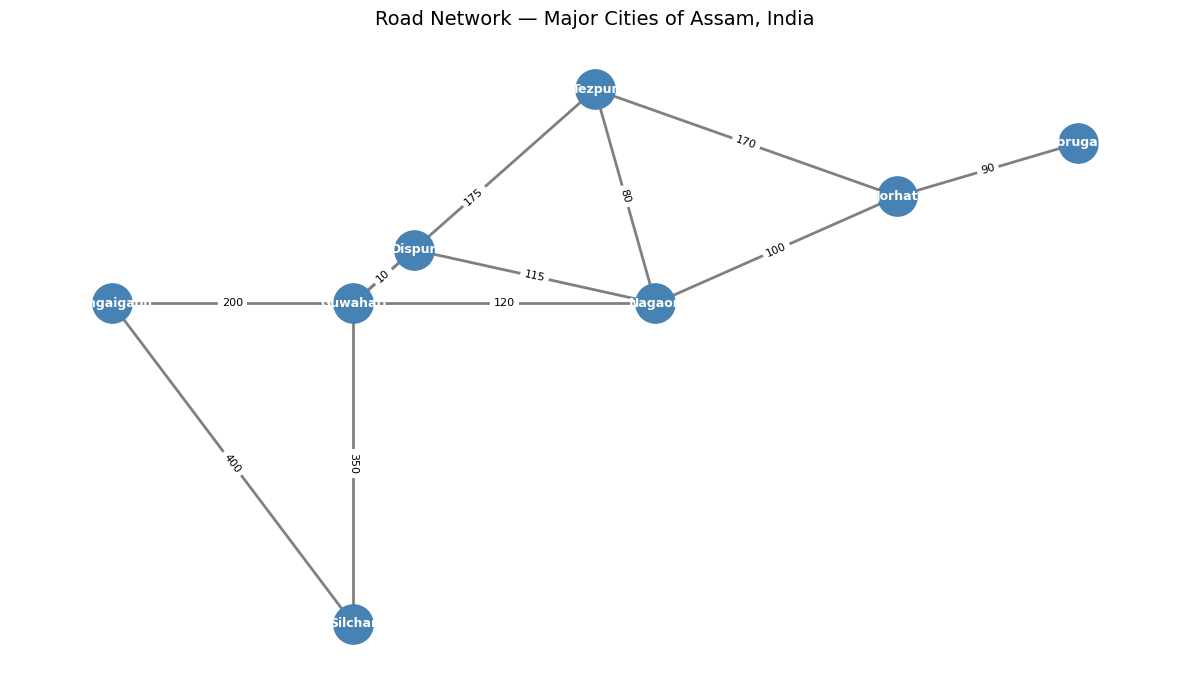

Network visualised.


In [4]:
# Approximate geographic positions for layout
pos = {
    'Guwahati':   (0.3, 0.5),
    'Dispur':     (0.35, 0.55),
    'Tezpur':     (0.5, 0.7),
    'Nagaon':     (0.55, 0.5),
    'Jorhat':     (0.75, 0.6),
    'Dibrugarh':  (0.9, 0.65),
    'Silchar':    (0.3, 0.2),
    'Bongaigaon': (0.1, 0.5),
}

edge_labels = nx.get_edge_attributes(G, 'weight')

plt.figure(figsize=(12, 7))
nx.draw_networkx_nodes(G, pos, node_color='steelblue', node_size=800)
nx.draw_networkx_labels(G, pos, font_color='white', font_size=9, font_weight='bold')
nx.draw_networkx_edges(G, pos, width=2, edge_color='gray')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.title('Road Network — Major Cities of Assam, India', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('assam_road_network.png', dpi=150, bbox_inches='tight')
plt.show()
print('Network visualised.')

## Step 3 — Find the Shortest Path using Dijkstra's Algorithm



In [5]:
source = 'Dispur'
target = 'Dibrugarh'

shortest_path = nx.dijkstra_path(G, source, target, weight='weight')
shortest_distance = nx.dijkstra_path_length(G, source, target, weight='weight')

print(f'Shortest path from {source} to {target}:')
print(' → '.join(shortest_path))
print(f'Total distance: {shortest_distance} km')

Shortest path from Dispur to Dibrugarh:
Dispur → Nagaon → Jorhat → Dibrugarh
Total distance: 305 km


## Step 4 — Visualise the Shortest Path

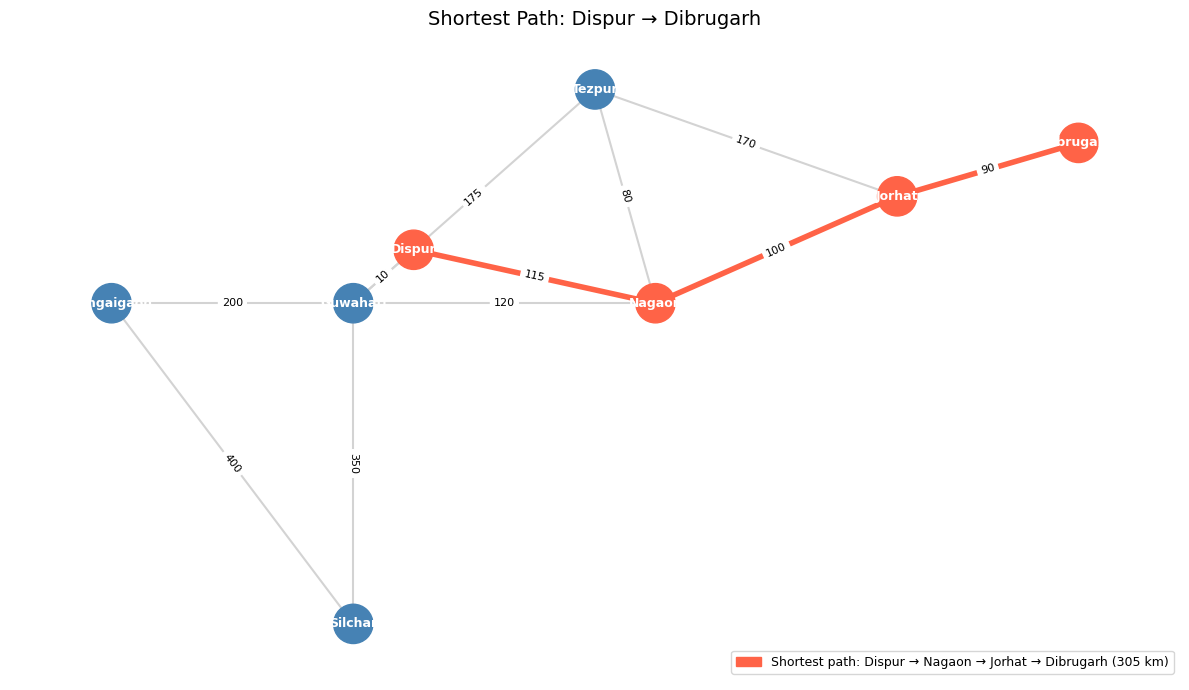

In [6]:
path_edges = list(zip(shortest_path[:-1], shortest_path[1:]))
path_nodes = set(shortest_path)

node_colors = ['tomato' if n in path_nodes else 'steelblue' for n in G.nodes()]
edge_colors = ['tomato' if (u, v) in path_edges or (v, u) in path_edges else 'lightgray' for u, v in G.edges()]
edge_widths = [4 if (u, v) in path_edges or (v, u) in path_edges else 1.5 for u, v in G.edges()]

plt.figure(figsize=(12, 7))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800)
nx.draw_networkx_labels(G, pos, font_color='white', font_size=9, font_weight='bold')
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

red_patch = mpatches.Patch(color='tomato', label=f'Shortest path: {" → ".join(shortest_path)} ({shortest_distance} km)')
plt.legend(handles=[red_patch], loc='lower right', fontsize=9)
plt.title(f'Shortest Path: {source} → {target}', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('assam_shortest_path.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Shortest Distances from Dispur to All Cities

In [7]:
all_distances = nx.single_source_dijkstra_path_length(G, 'Dispur', weight='weight')

print('Shortest distances from Dispur (km):')
print('-' * 35)
for city, dist in sorted(all_distances.items(), key=lambda x: x[1]):
    print(f'{city:<15} {dist} km')

Shortest distances from Dispur (km):
-----------------------------------
Dispur          0 km
Guwahati        10 km
Nagaon          115 km
Tezpur          185 km
Bongaigaon      210 km
Jorhat          215 km
Dibrugarh       305 km
Silchar         360 km


## Summary

| Concept | What it means here |
|---|---|
| Graph | Road network of Assam |
| Node | A city |
| Edge | A road between two cities |
| Weight | Road distance in km |
| Dijkstra's Algorithm | Finds the shortest route |

